In [1]:
!python --version

Python 3.11.14


In [2]:
import os, sys
import pandas as pd

from pathlib import Path

ROOT = Path().resolve().parent
SRC = os.path.join(ROOT, "src")

if str(SRC) not in sys.path:
    sys.path.append(str(SRC))

print("ROOT:", ROOT)
print("SRC added:", SRC)

from libs.calc_degs_lib import CALC_DEGS
from libs.tcga_gdc_lib import *
from libs.Basic import *


ROOT: /home/flavio/uv/perturb_agent
SRC added: /home/flavio/uv/perturb_agent/src


### Defaults

In [3]:
ROOT = Path().resolve().parent
root0 = ROOT / "data"

gdc = GDC(root0=root0)

os.listdir(root0)[:10]


['cancer', 'reactome', 'vector_store', 'TCGA', 'gdc_programs.txt']

### Get all programs

In [4]:
force=False
verbose=True

prog_list = gdc.get_gdc_progams(force=force, verbose=verbose)


File read at '/home/flavio/uv/perturb_agent/data/gdc_programs.txt'


In [5]:
np.array(prog_list)

array(['TCGA', 'MATCH', 'TARGET', 'CGCI', 'CMI', 'APOLLO', 'BEATAML1.0',
       'CPTAC', 'MP2PRT', 'ALCHEMIST', 'CCDI', 'CCG', 'CDDP_EAGLE',
       'CTSP', 'EXCEPTIONAL_RESPONDERS', 'FM', 'HCMI', 'MMRF', 'NCICCR',
       'OHSU', 'ORGANOID', 'RC', 'REBC', 'TRIO', 'VAREPOP', 'WCDT'],
      dtype='<U22')

### Primary sites given a program

In [6]:
gdc.url_gdc_project

'https://api.gdc.cancer.gov/projects'

In [7]:
force=False
verbose=False

prog_id = 'TCGA'

gdc.set_program(prog_id)
df_psi = gdc.get_primary_sites(prog_id=prog_id, force=False, verbose=verbose)

i=0
primary_site = df_psi.iloc[i].primary_site
gdc.set_primary_site(primary_site=primary_site) 


True

In [8]:
df_psi.loc[:, ('psi_id', 'primary_site')]

,psi_id,primary_site
0,TCGA-ACC,Adrenal gland
1,TCGA-PCPG,"Adrenal gland, Retroperitoneum and peritoneum,..."
2,TCGA-BLCA,Bladder
3,TCGA-LGG,Brain
4,TCGA-GBM,Brain
5,TCGA-BRCA,Breast
6,TCGA-LUAD,Bronchus and lung
7,TCGA-LUSC,Bronchus and lung
8,TCGA-MESO,"Bronchus and lung, Heart, mediastinum, and pleura"
9,TCGA-CESC,"Cervix uteri, Ovary"


In [9]:
verbose=False

i=5
primary_site = df_psi.iloc[i].primary_site
print(">>", primary_site, end=" ")

cluster_type='UMAP'

dfw, dfh, dfstat, dfpiv = gdc.entropy_analysis_for_primary_site(cluster_type=cluster_type, primary_site=primary_site,
                                                                Kmin=2, Kmax=10, 
                                                                min_barcodes=3, min_genes=5, verbose=verbose)

print(len(dfw))

print("\n----------- end ------------")

dfw

>> Breast 9

----------- end ------------


,psi_id,primary_site,min_barcodes,min_genes,k,n_clusters,weighted_mean_hnorm,mean_hnorm,std_hnorm,min_cluster_size,max_cluster_size,n_small_clusters_lt3
3,TCGA-BRCA,Breast,3,5,5,4,0.918586,0.923369,0.075124,11,17,0
2,TCGA-BRCA,Breast,3,5,4,3,0.919062,0.918256,0.059868,18,22,0
1,TCGA-BRCA,Breast,3,5,3,2,0.930537,0.926160,0.046426,26,34,0
0,TCGA-BRCA,Breast,3,5,2,1,0.951812,0.951812,NaN,60,60,0
5,TCGA-BRCA,Breast,3,5,7,4,0.959520,0.964806,0.045742,8,13,0
4,TCGA-BRCA,Breast,3,5,6,4,0.962341,0.959584,0.029706,9,17,0
6,TCGA-BRCA,Breast,3,5,8,4,0.991901,0.992096,0.004365,7,10,0
7,TCGA-BRCA,Breast,3,5,9,4,0.993272,0.993272,0.003218,7,9,0
8,TCGA-BRCA,Breast,3,5,10,4,0.993313,0.993330,0.003229,7,9,0


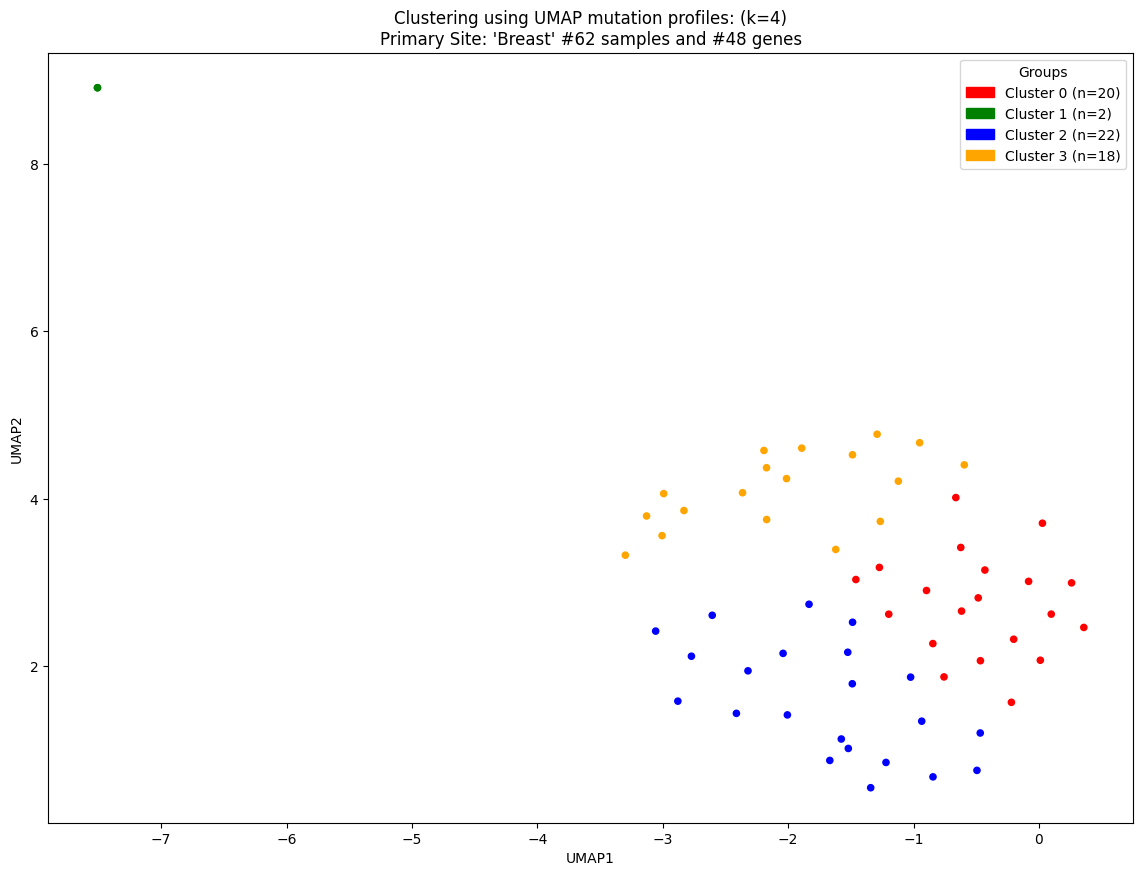

In [10]:
fig, embedding, labels = gdc.plot_UMAP(dfpiv, k=4, figsize=(14, 10))

>>> calc_HDBSCAN MIN_CLUSTER_SIZE 3


/home/flavio/uv/perturb_agent/.venv/lib/python3.11/site-packages/sklearn/manifold/_mds.py:771: FutureWarning: The `dissimilarity` parameter is deprecated and will be removed in 1.10. Use `metric` instead.
  warnings.warn(
/home/flavio/uv/perturb_agent/.venv/lib/python3.11/site-packages/sklearn/manifold/_mds.py:383: UserWarning: Explicit initial positions passed: performing only one init of the MDS instead of 8
  warnings.warn(


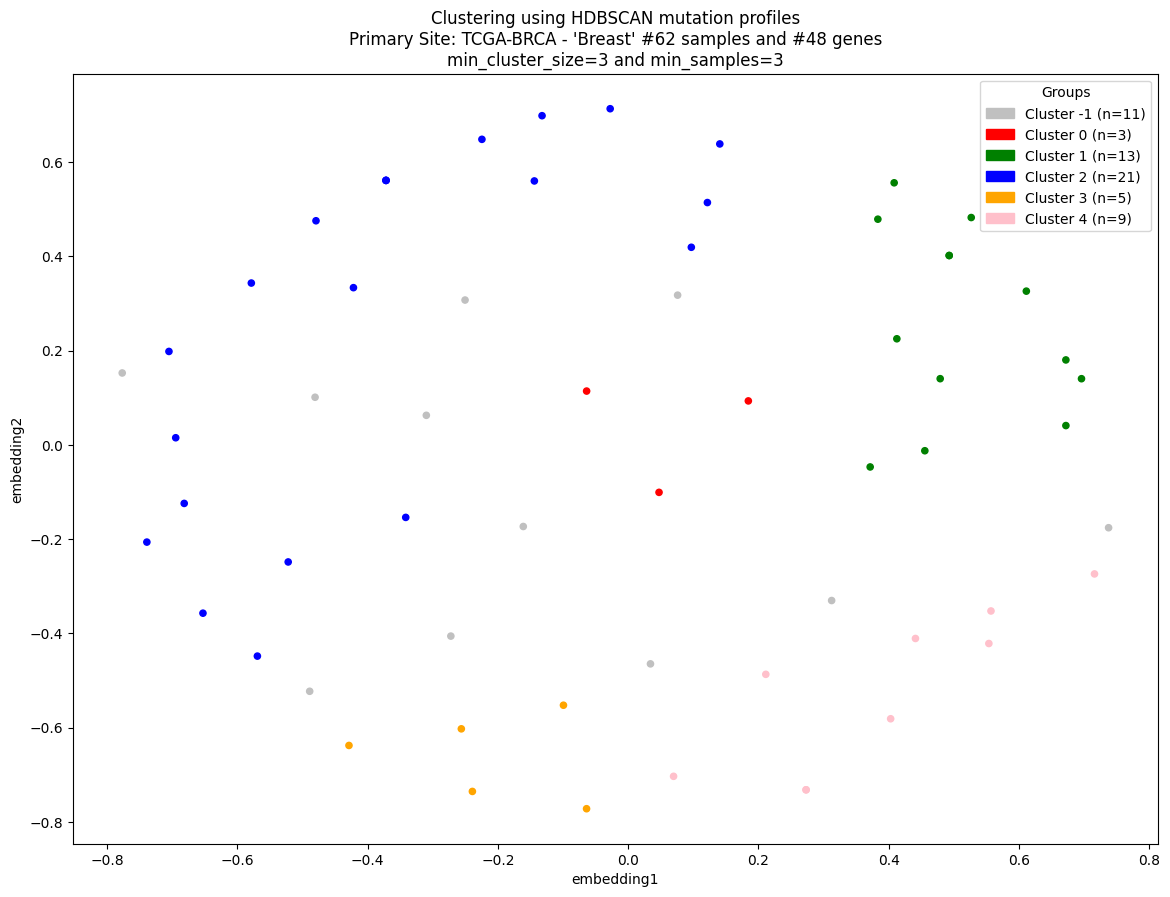

In [15]:
fig, embedding, labels, d = gdc.plot_HDBSCAN(dfpiv, min_cluster_size=3, min_samples=3, figsize=(14, 10))

In [ ]:
print(dfpiv.shape)

dfpiv.iloc[:30, :15]

In [ ]:
dfpiv.sum(axis=0)

In [ ]:
gdc.dfpiv.shape

In [ ]:
gdc.dfpiv